# 11. Counterfactual Explanations and Actionable Recourse

The previous notebook studied interaction structure: where a model behaves differently across contexts. This notebook moves from "how does the model behave?" to a more prescriptive question:

> What would need to change for this model to assign a different outcome?

That question leads to **counterfactual explanations** and **algorithmic recourse**. Counterfactual explanations are attractive because they sound like actionable advice: "If this account had fewer incidents and better adoption, the model would not flag it for review." But this is exactly where decision science needs discipline. A feature edit needs feasibility review, and a model flip needs evidence that the real-world outcome would improve.

We will build a recourse workflow from scratch. The goal is not to use a black-box recourse package. The goal is to expose the pieces every professional recourse system needs: target outcome, distance metric, actionability constraints, feasibility constraints, plausibility checks, robustness checks, and causal caveats.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Define counterfactual explanations as constrained optimization problems.
2. Distinguish model-only counterfactuals from actionable recourse.
3. Encode immutable, mutable, monotone, and costly feature changes.
4. Generate feasible recourse candidates for a black-box risk model using constrained search.
5. Compare nearest-observed counterfactuals, low-cost action plans, and causal intervention warnings.
6. Audit recourse burden across operational segments.
7. Explain why recourse should be monitored over time as models and operating conditions change.

## 1. Counterfactual Explanation As Optimization

Let $f(x)$ be a fitted model and let $x_0$ be the case we want to explain. Suppose the current model output is unfavorable. A basic counterfactual explanation solves

$$
\min_{x'} \; d(x',x_0)
\quad \text{subject to} \quad
f(x') \in \mathcal Y_{\text{desired}}.
$$

For a binary risk model, the desired set might be

$$
\mathcal Y_{\text{desired}} = \{x': f(x') \leq \tau\},
$$

where $\tau$ is the risk threshold below which no specialist review is triggered.

This definition is intentionally incomplete. It asks for a nearby input vector, but does not yet say whether the suggested changes are actionable, feasible, stable, or beneficial in the real world. Wachter, Mittelstadt, and Russell (2017) helped popularize counterfactual explanations as model-agnostic "what if" explanations. Ustun, Spangher, and Liu (2019) emphasized that recourse must respect actionability and cost constraints, especially in consequential decisions.

## 2. From Counterfactuals To Recourse

A recourse problem adds feasible actions. Let $a$ be an action that transforms the current case into a new feature vector $T(x_0,a)$. A recourse problem is closer to

$$
\min_{a \in \mathcal A(x_0)} \; C(a;x_0)
\quad \text{subject to} \quad
f(T(x_0,a)) \leq \tau,
$$

where:

- $\mathcal A(x_0)$ is the set of feasible actions for this case;
- $C(a;x_0)$ is the cost or burden of the action;
- $T(x_0,a)$ maps actions into model features;
- $\tau$ is the desired risk threshold.

This distinction matters. A counterfactual may say that an account would not be flagged if it were in a different region, were smaller, or had no legacy integration. Those statements may explain the model boundary, but they are not useful recourse. Recourse should recommend changes that the stakeholder can actually make.

## 3. Recourse Desiderata

| Desideratum | Practical question | Failure mode if ignored |
|---|---|---|
| Validity | Does the changed point achieve the desired model outcome? | Advice does not flip the model decision |
| Proximity | Is the changed point close to the original point? | Explanation is too far away to be meaningful |
| Sparsity | Does it change only a few features? | Advice is cognitively and operationally overwhelming |
| Actionability | Are the changed features under stakeholder control? | The recommendation asks for impossible changes |
| Feasibility | Do changes respect domain constraints and directionality? | The plan violates business or physical reality |
| Plausibility | Does the changed point resemble real data? | The model is queried in unsupported feature space |
| Robustness | Does recourse survive model updates or data shift? | Stakeholders follow advice that later stops working |
| Causal relevance | Would the action improve the real outcome, as well as the model score? | The plan optimizes acceptance without improvement |

Karimi, Schölkopf, and Valera (2020) argue that moving from counterfactual feature vectors to interventions requires causal reasoning. Karimi, von Kügelgen, and Schölkopf (2020) further emphasize that recourse under imperfect causal knowledge is inherently uncertain.

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 2061
sns.set_theme(style='whitegrid', context='notebook')
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_colwidth', 120)

In [2]:
# Section focus: 3. Recourse Desiderata.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='440px'):
    """Display table for the 11. Counterfactual Explanations and Actionable Recourse notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('max-width', max_width), ('text-align', 'left'), ('vertical-align', 'top')]},
    ])
    display(styler)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))


def predict_risk(model, data, features):
    """Carry out the predict risk step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(data[features])[:, 1]


def classification_metrics(y_true, prob):
    """Carry out the classification metrics step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    prob : object
        Rate or probability parameter controlling this calculation.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    clipped = np.clip(prob, 1e-6, 1 - 1e-6)
    return {
        'roc_auc': roc_auc_score(y_true, prob),
        'average_precision': average_precision_score(y_true, prob),
        'brier_score': brier_score_loss(y_true, prob),
        'log_loss': log_loss(y_true, clipped),
        'mean_predicted_risk': float(np.mean(prob)),
    }

This result is an interpretation diagnostic. For Recourse Desiderata, look at whether the explanation is stable, plausible, and useful for stakeholder review. When reasonable explanation settings lead to different conclusions, the model story should stay provisional.


## 4. Synthetic Decision Case: Account Review Recourse

We continue in the customer-success domain. The model predicts whether an account needs specialist review before renewal. A recourse explanation should answer:

> What feasible actions could move a high-risk account below the specialist-review threshold?

The important distinction is between **editing a feature** and **taking an action**. For example:

| Model feature | Directly actionable? | Example action interpretation |
|---|---|---|
| `usage_gap` | Partly | Adoption campaign, workflow redesign, targeted product enablement |
| `training_gap` | Yes | Training program, enablement sessions, documentation campaign |
| `open_tickets` | Yes | Support sprint, backlog triage, escalation routing |
| `billing_delay_days` | Yes | Billing resolution workflow |
| `executive_sponsor` | Sometimes | Assign or activate an executive sponsor |
| `recent_incidents` | Not directly in current window | Future incident prevention, not an instant edit to history |
| `legacy_integration` | No in near term | Migration project, not ordinary short-term recourse |
| `international_region` | No | Contextual attribute |
| `account_size` | No | Structural attribute |
| `random_noise_feature` | No | Should never be used for advice |

In [3]:
# Section focus: 4. Synthetic Decision Case: Account Review Recourse.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_account_review_data(n=6000, seed=RANDOM_SEED):
    """Construct the account review data helper used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    account_size = rng.normal(0, 1, n)
    international_region = rng.binomial(1, sigmoid(-0.55 + 0.50 * account_size), n)
    legacy_integration = rng.binomial(1, sigmoid(-0.85 + 0.60 * international_region + 0.30 * account_size), n)
    executive_sponsor = rng.binomial(1, sigmoid(-0.10 + 0.82 * account_size - 0.30 * legacy_integration), n)

    maturity = rng.normal(0, 1, n) + 0.25 * executive_sponsor - 0.20 * legacy_integration - 0.12 * international_region
    usage_gap = np.clip(sigmoid(-0.20 - 0.92 * maturity + rng.normal(0, 0.68, n)), 0.02, 0.98)
    training_gap = np.clip(sigmoid(-0.08 - 0.80 * maturity + 0.52 * usage_gap + rng.normal(0, 0.62, n)), 0.02, 0.98)

    ticket_lambda = np.exp(0.30 + 0.95 * usage_gap + 0.72 * training_gap + 0.25 * legacy_integration)
    open_tickets = rng.poisson(np.clip(ticket_lambda, 0.2, 9.5))
    incident_lambda = np.exp(-1.35 + 0.23 * open_tickets + 0.68 * legacy_integration + 0.22 * international_region)
    recent_incidents = rng.poisson(np.clip(incident_lambda, 0.04, 7.5))

    billing_delay_days = np.clip(rng.gamma(1.6 + 0.50 * legacy_integration, 1.35, n), 0, 13)
    adoption_volatility = np.abs(rng.normal(0.30 + 0.62 * usage_gap + 0.22 * international_region, 0.20, n))
    random_noise_feature = rng.normal(0, 1, n)

    ticket_pressure = np.maximum(open_tickets - 3, 0)
    incident_pressure = np.maximum(recent_incidents - 2, 0)

    logit = (
        -4.25
        + 1.35 * usage_gap
        + 1.15 * training_gap
        + 0.18 * open_tickets
        + 0.42 * recent_incidents
        + 0.11 * billing_delay_days
        + 0.70 * legacy_integration
        + 0.38 * international_region
        - 0.85 * executive_sponsor
        + 1.70 * usage_gap * training_gap
        + 0.25 * ticket_pressure * incident_pressure
        + 0.82 * recent_incidents * (1 - executive_sponsor)
        + 0.62 * adoption_volatility * legacy_integration
    )

    true_risk = sigmoid(logit)
    needs_specialist_review = rng.binomial(1, true_risk)

    return pd.DataFrame({
        'account_size': account_size,
        'usage_gap': usage_gap,
        'training_gap': training_gap,
        'open_tickets': open_tickets,
        'recent_incidents': recent_incidents,
        'billing_delay_days': billing_delay_days,
        'adoption_volatility': adoption_volatility,
        'executive_sponsor': executive_sponsor,
        'international_region': international_region,
        'legacy_integration': legacy_integration,
        'random_noise_feature': random_noise_feature,
        'true_risk': true_risk,
        'needs_specialist_review': needs_specialist_review,
    })


df = make_account_review_data()
TARGET = 'needs_specialist_review'
FEATURES = [
    'account_size', 'usage_gap', 'training_gap', 'open_tickets', 'recent_incidents',
    'billing_delay_days', 'adoption_volatility', 'executive_sponsor',
    'international_region', 'legacy_integration', 'random_noise_feature'
]
ACTIONABLE_FEATURES = ['usage_gap', 'training_gap', 'open_tickets', 'billing_delay_days', 'executive_sponsor']
SLOW_OR_NONACTIONABLE_FEATURES = ['recent_incidents', 'legacy_integration', 'international_region', 'account_size', 'random_noise_feature']

train_df, test_df = train_test_split(df, test_size=0.30, random_state=RANDOM_SEED, stratify=df[TARGET])

summary = pd.DataFrame([
    {'quantity': 'Rows', 'value': len(df)},
    {'quantity': 'Train rows', 'value': len(train_df)},
    {'quantity': 'Test rows', 'value': len(test_df)},
    {'quantity': 'Review rate', 'value': df[TARGET].mean()},
    {'quantity': 'Correlation: usage gap and training gap', 'value': df[['usage_gap', 'training_gap']].corr().iloc[0, 1]},
    {'quantity': 'Correlation: tickets and incidents', 'value': df[['open_tickets', 'recent_incidents']].corr().iloc[0, 1]},
])
display_table(summary)
display_table(df[FEATURES + [TARGET]].head(6))

,quantity,value
0,Rows,6000.000
1,Train rows,4200.000
2,Test rows,1800.000
3,Review rate,0.383
4,Correlation: usage gap and training gap,0.696
5,Correlation: tickets and incidents,0.560


,account_size,usage_gap,training_gap,open_tickets,recent_incidents,billing_delay_days,adoption_volatility,executive_sponsor,international_region,legacy_integration,random_noise_feature,needs_specialist_review
0,-0.510,0.346,0.520,0,0,2.212,0.408,0,0,0,-1.782,0
1,-0.691,0.503,0.596,5,0,1.891,0.725,0,0,0,1.520,0
2,0.415,0.391,0.812,3,0,6.100,0.692,0,0,0,-0.913,0
3,1.578,0.352,0.252,4,3,2.117,1.128,1,1,0,0.687,0
4,-0.011,0.610,0.348,2,0,1.380,0.543,1,0,0,0.090,0
5,-0.267,0.108,0.307,2,0,4.025,0.491,0,0,0,0.696,0


Synthetic Decision Case: Account Review Recourse should make the model story easier to inspect instead of merely more polished.


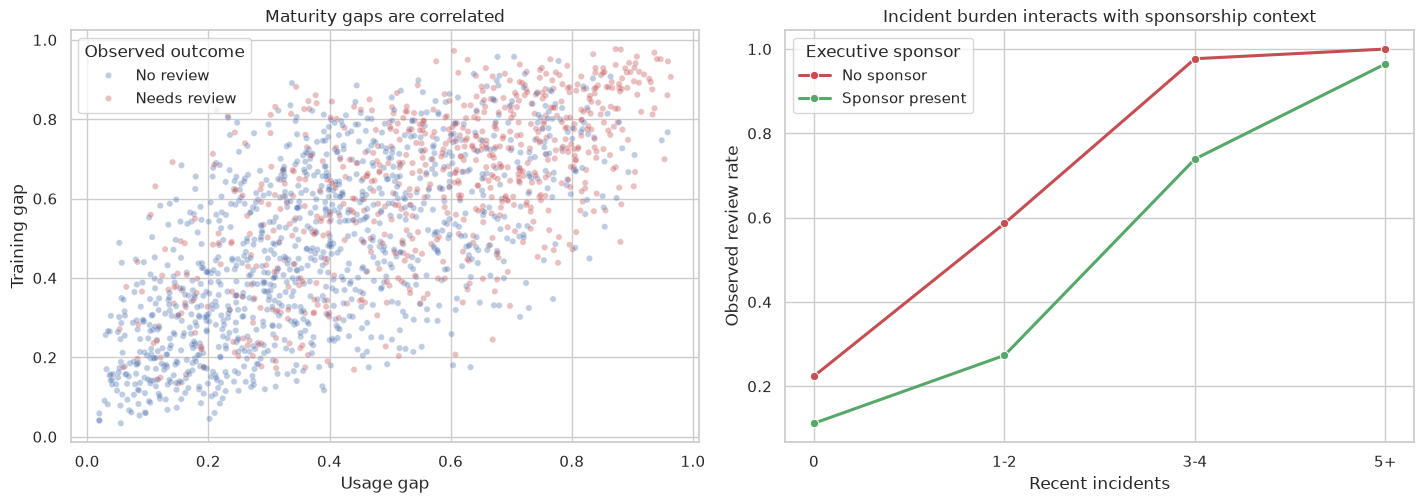

In [4]:
# Section focus: 4. Synthetic Decision Case: Account Review Recourse.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.2))

plot_sample = df.sample(1800, random_state=RANDOM_SEED).copy()
plot_sample['review_label'] = np.where(plot_sample[TARGET].eq(1), 'Needs review', 'No review')
sns.scatterplot(
    data=plot_sample,
    x='usage_gap',
    y='training_gap',
    hue='review_label',
    hue_order=['No review', 'Needs review'],
    palette={'No review': '#4c72b0', 'Needs review': '#c44e52'},
    alpha=0.36,
    s=20,
    ax=axes[0],
)
axes[0].set_title('Maturity gaps are correlated')
axes[0].set_xlabel('Usage gap')
axes[0].set_ylabel('Training gap')
axes[0].legend(title='Observed outcome', loc='upper left')

incident_bins = pd.cut(df['recent_incidents'], bins=[-0.1, 0.5, 2.5, 4.5, 20], labels=['0', '1-2', '3-4', '5+'])
incident_summary = (
    df.assign(incident_bin=incident_bins, sponsor_label=np.where(df['executive_sponsor'].eq(1), 'Sponsor present', 'No sponsor'))
      .groupby(['incident_bin', 'sponsor_label'], observed=False)[TARGET]
      .agg(['mean', 'size'])
      .reset_index()
)
sns.lineplot(
    data=incident_summary,
    x='incident_bin',
    y='mean',
    hue='sponsor_label',
    marker='o',
    linewidth=2.2,
    palette={'Sponsor present': '#55a868', 'No sponsor': '#c44e52'},
    ax=axes[1],
)
axes[1].set_title('Incident burden interacts with sponsorship context')
axes[1].set_xlabel('Recent incidents')
axes[1].set_ylabel('Observed review rate')
axes[1].legend(title='Executive sponsor')

plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Synthetic Decision Case: Account Review Recourse, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A weak explanation creates extra review work and makes the recommendation harder to defend.


### Discussion of The Data Design

The setup is intentionally similar to recent notebooks so the interpretation tools can be compared. The important recourse issue is that many risk drivers are correlated and only some are actionable. A naive counterfactual may reduce risk by changing `legacy_integration` or `recent_incidents`, but those are not ordinary short-term actions.

The account-review setting makes recourse realistic because the features differ in actionability. Training completion can plausibly be improved, sponsorship can sometimes be strengthened, and documentation can be cleaned up. Recent incidents, legacy integration, and account complexity are much harder to change quickly.

The experiment asks whether a counterfactual explanation respects that distinction. A mathematically small change is not always an actionable recommendation. The data design forces the notebook to separate feasible recourse from changes that only look good in feature space.


## 5. Fit The Risk Model

We fit three models again, but the recourse exercises will focus on the gradient boosting model. A counterfactual method can be model-agnostic: it only needs a prediction function. Still, model quality matters. Recourse for a poor model is just advice for manipulating a poor model.

In [5]:
# Section focus: 5. Fit The Risk Model.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

logit_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=4000, C=0.9)),
])
forest_model = RandomForestClassifier(
    n_estimators=320,
    min_samples_leaf=24,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
gb_model = HistGradientBoostingClassifier(
    max_iter=260,
    learning_rate=0.045,
    max_leaf_nodes=24,
    l2_regularization=0.03,
    random_state=RANDOM_SEED,
)

models = {
    'Logistic regression': logit_model,
    'Random forest': forest_model,
    'Gradient boosting': gb_model,
}

metric_rows = []
for name, model in models.items():
    model.fit(train_df[FEATURES], train_df[TARGET])
    prob = predict_risk(model, test_df, FEATURES)
    metric_rows.append({'model': name, **classification_metrics(test_df[TARGET], prob)})

metrics = pd.DataFrame(metric_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display_table(metrics)

test_predictions = pd.Series(predict_risk(gb_model, test_df, FEATURES), index=test_df.index, name='predicted_risk')
TARGET_RISK = 0.42
REVIEW_THRESHOLD = 0.50

,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Logistic regression,0.892,0.863,0.125,0.391,0.381
1,Random forest,0.884,0.855,0.131,0.415,0.379
2,Gradient boosting,0.879,0.854,0.131,0.413,0.373


In Fit The Risk Model, pay attention to whether the explanation changes when the analyst changes plausible settings. Use this instability to decide whether more diagnostics are needed.


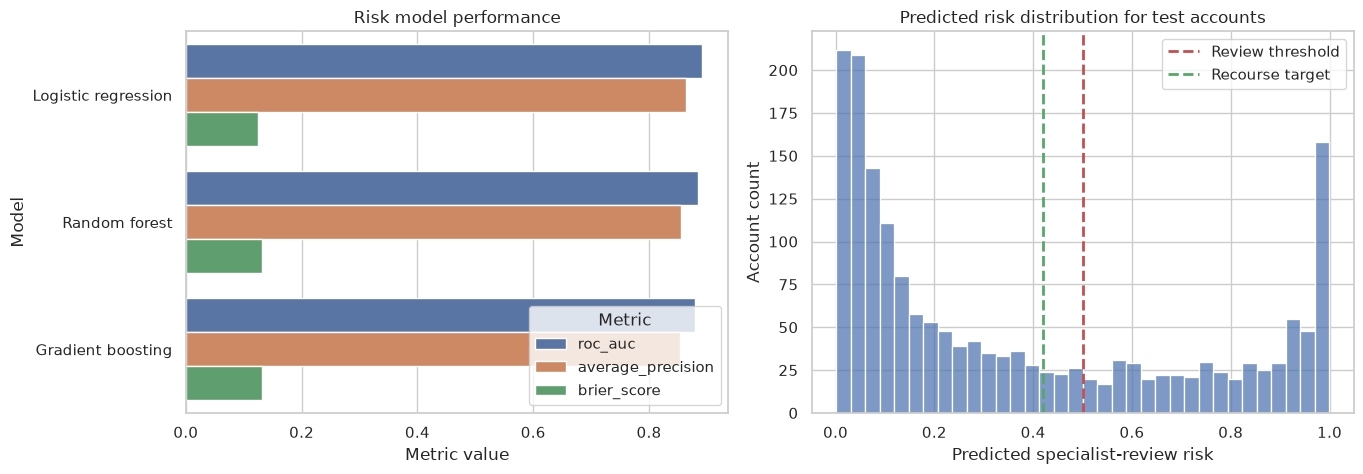

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.9))

metric_long = metrics.melt(id_vars='model', value_vars=['roc_auc', 'average_precision', 'brier_score'], var_name='metric', value_name='value')
sns.barplot(data=metric_long, x='value', y='model', hue='metric', ax=axes[0], palette='deep')
axes[0].set_title('Risk model performance')
axes[0].set_xlabel('Metric value')
axes[0].set_ylabel('Model')
axes[0].legend(title='Metric', loc='lower right')

sns.histplot(test_predictions, bins=34, color='#4c72b0', alpha=0.72, ax=axes[1])
axes[1].axvline(REVIEW_THRESHOLD, color='#c44e52', linestyle='--', linewidth=2, label='Review threshold')
axes[1].axvline(TARGET_RISK, color='#55a868', linestyle='--', linewidth=2, label='Recourse target')
axes[1].set_title('Predicted risk distribution for test accounts')
axes[1].set_xlabel('Predicted specialist-review risk')
axes[1].set_ylabel('Account count')
axes[1].legend()

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Fit The Risk Model, look at whether the explanation is stable, plausible, and useful for stakeholder review. A story that moves across samples or baselines needs a careful qualification in the final report.


### Discussion of The Model

The model is strong enough for explanation exercises. The recourse target is deliberately stricter than the review threshold. We want more than a point that barely crosses from 0.501 to 0.499. A margin below the decision threshold makes the advice less brittle.

## 6. A Focal Account

We will choose a high-risk no-sponsor account for which feasible recourse exists. The selection is not random: we want a case where the mechanics are visible and the action set is not empty.

In [7]:
# Section focus: 6. A Focal Account.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def unique_sorted(values):
    """Carry out the unique sorted step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the unique sorted calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the unique sorted calculation and reused by later cells.
    """
    cleaned = []
    for value in values:
        if isinstance(value, (int, np.integer)):
            candidate = int(max(value, 0))
        else:
            candidate = float(np.clip(value, 0, 1))
        if candidate not in cleaned:
            cleaned.append(candidate)
    return cleaned


def action_options(x, include_incident_edits=False):
    """Carry out the action options step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    include_incident_edits : object
        The include incident edits setting that controls the action options calculation in this notebook.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the action options workflow.
    """
    usage = float(x['usage_gap'])
    training = float(x['training_gap'])
    tickets = int(x['open_tickets'])
    billing = float(x['billing_delay_days'])
    sponsor = int(x['executive_sponsor'])
    incidents = int(x['recent_incidents'])

    options = {
        'usage_gap': unique_sorted([usage, usage - 0.15, usage - 0.35, 0.05]),
        'training_gap': unique_sorted([training, training - 0.15, training - 0.35, 0.05]),
        'open_tickets': unique_sorted([tickets, tickets - 2, tickets - 5]),
        'billing_delay_days': unique_sorted([billing, billing - 4.0, 0.0]),
        'executive_sponsor': [sponsor] if sponsor == 1 else [0, 1],
    }
    if include_incident_edits:
        options['recent_incidents'] = unique_sorted([incidents, incidents - 2, 0])
    return options


def action_cost(original, candidate, include_incident_edits=False):
    """Carry out the action cost step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    original : object
        The original setting that controls the action cost calculation in this notebook.
    candidate : object
        Candidate action, variable, model, or explanation being compared.
    include_incident_edits : object
        The include incident edits setting that controls the action cost calculation in this notebook.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the action cost workflow.
    """
    cost = 0.0
    cost += 2.30 * max(original['usage_gap'] - candidate['usage_gap'], 0)
    cost += 2.10 * max(original['training_gap'] - candidate['training_gap'], 0)
    cost += 0.42 * max(original['open_tickets'] - candidate['open_tickets'], 0)
    cost += 0.16 * max(original['billing_delay_days'] - candidate['billing_delay_days'], 0)
    cost += 1.35 * max(candidate['executive_sponsor'] - original['executive_sponsor'], 0)
    if include_incident_edits:
        cost += 1.75 * max(original['recent_incidents'] - candidate['recent_incidents'], 0)
    return cost


def generate_action_candidates(original, model, features, target_risk=TARGET_RISK, include_incident_edits=False):
    """Generate action candidates for the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    original : object
        The original setting that controls the action candidates calculation in this notebook.
    model : object
        Fitted model or model specification used by this step.
    features : object
        Feature column names or feature matrix used by the model.
    target_risk : object
        Score or risk value used for ranking, thresholding, or diagnostics.
    include_incident_edits : object
        The include incident edits setting that controls the action candidates calculation in this notebook.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the action candidates workflow.
    """
    options = action_options(original, include_incident_edits=include_incident_edits)
    keys = list(options.keys())
    base = original.copy()
    rows = []
    for values in itertools.product(*[options[k] for k in keys]):
        candidate = base.copy()
        for key, value in zip(keys, values):
            candidate[key] = value
        rows.append({feature: candidate[feature] for feature in features})

    candidate_features = pd.DataFrame(rows)
    risks = predict_risk(model, candidate_features, features)
    candidates = candidate_features[keys].copy()
    candidates['predicted_risk'] = risks
    candidates['valid_recourse'] = candidates['predicted_risk'] <= target_risk
    candidates['action_cost'] = [
        action_cost(original, candidate_features.iloc[i], include_incident_edits=include_incident_edits)
        for i in range(len(candidate_features))
    ]
    candidates['action_count'] = [
        sum(abs(float(candidate_features.iloc[i][key] - original[key])) > 1e-9 for key in keys)
        for i in range(len(candidate_features))
    ]
    return candidates.sort_values(
        ['valid_recourse', 'action_cost', 'action_count', 'predicted_risk'],
        ascending=[False, True, True, True],
    ).reset_index(drop=True)

def best_candidate(candidates):
    """Carry out the best candidate step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    candidates : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    
    Returns
    -------
    object
        Intermediate result produced by the best candidate calculation and reused by later cells.
    """
    valid = candidates[candidates['valid_recourse']]
    if valid.empty:
        return None
    return valid.sort_values(['action_cost', 'action_count', 'predicted_risk']).iloc[0]

candidate_indices = (
    test_predictions[(test_predictions.between(0.62, 0.90)) & (test_df['executive_sponsor'].eq(0)) & (test_df['recent_incidents'].ge(1))]
    .sub(0.76)
    .abs()
    .sort_values()
    .index[:100]
)

focal_index = None
focal_candidates = None
for idx in candidate_indices:
    candidates = generate_action_candidates(test_df.loc[idx], gb_model, FEATURES, target_risk=TARGET_RISK, include_incident_edits=False)
    if candidates['valid_recourse'].any():
        focal_index = idx
        focal_candidates = candidates
        break

if focal_index is None:
    fallback_pool = test_predictions[test_predictions > REVIEW_THRESHOLD].sort_values().index[:120]
    for idx in fallback_pool:
        candidates = generate_action_candidates(test_df.loc[idx], gb_model, FEATURES, target_risk=TARGET_RISK, include_incident_edits=False)
        if candidates['valid_recourse'].any():
            focal_index = idx
            focal_candidates = candidates
            break

if focal_index is None:
    raise RuntimeError('No feasible focal account found. Relax TARGET_RISK or action grid.')

focal = test_df.loc[focal_index].copy()
focal_risk = float(test_predictions.loc[focal_index])

focal_summary = pd.DataFrame([{
    'row_index': focal_index,
    'observed_outcome': int(focal[TARGET]),
    'predicted_risk': focal_risk,
    'review_threshold': REVIEW_THRESHOLD,
    'recourse_target': TARGET_RISK,
    **{feature: focal[feature] for feature in FEATURES},
}])
display_table(focal_summary, max_width='520px')

,row_index,observed_outcome,predicted_risk,review_threshold,recourse_target,account_size,usage_gap,training_gap,open_tickets,recent_incidents,billing_delay_days,adoption_volatility,executive_sponsor,international_region,legacy_integration,random_noise_feature
0,1947,1,0.761,0.500,0.420,0.219,0.332,0.418,4.000,2.000,1.173,0.417,0.000,0.000,1.000,-0.688


Use the explanation as a stress test of the model narrative. In A Focal Account, the displayed reasons should make sense with the data-generating story and the operating decision. Use method disagreement to decide where additional diagnostics are needed.


### Discussion of The Focal Account

This account is above the review threshold. The recourse target asks for a lower-risk model state with a margin beyond a barely favorable classification. The action search will hold structural context fixed and only change features we are willing to treat as actionable in the short term.

## 7. Nearest Observed Counterfactual Is Not Necessarily Recourse

A tempting model-agnostic method is to find a similar observed account that already has the desired model outcome. This produces a plausible point because it comes from real data. But it may change features the focal account cannot change.

In [8]:
# Section focus: 7. Nearest Observed Counterfactual Is Not Necessarily Recourse.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

support_scaler = StandardScaler().fit(train_df[FEATURES])
train_predictions = pd.Series(predict_risk(gb_model, train_df, FEATURES), index=train_df.index)
low_risk_pool = train_df.loc[train_predictions <= TARGET_RISK].copy()

focal_scaled = support_scaler.transform(pd.DataFrame([focal[FEATURES]], columns=FEATURES))
pool_scaled = support_scaler.transform(low_risk_pool[FEATURES])
distances = np.sqrt(((pool_scaled - focal_scaled) ** 2).sum(axis=1))
nearest_pos = int(np.argmin(distances))
nearest_idx = low_risk_pool.index[nearest_pos]
nearest_cf = low_risk_pool.loc[nearest_idx]
nearest_risk = float(train_predictions.loc[nearest_idx])

change_rows = []
for feature in FEATURES:
    before = focal[feature]
    after = nearest_cf[feature]
    delta = after - before
    if abs(float(delta)) > 0.05 or feature in ['executive_sponsor', 'international_region', 'legacy_integration'] and int(before) != int(after):
        change_rows.append({
            'feature': feature,
            'focal_value': before,
            'nearest_low_risk_value': after,
            'delta': delta,
            'actionability': 'Actionable' if feature in ACTIONABLE_FEATURES else 'Not short-term actionable',
        })

nearest_summary = pd.DataFrame([{
    'nearest_observed_index': nearest_idx,
    'focal_risk': focal_risk,
    'nearest_observed_risk': nearest_risk,
    'standardized_distance': float(distances[nearest_pos]),
    'number_of_changed_features_shown': len(change_rows),
}])
display_table(nearest_summary)
display_table(pd.DataFrame(change_rows).sort_values('actionability'))

,nearest_observed_index,focal_risk,nearest_observed_risk,standardized_distance,number_of_changed_features_shown
0,3162,0.761,0.251,1.389,6


,feature,focal_value,nearest_low_risk_value,delta,actionability
1,usage_gap,0.332,0.129,-0.204,Actionable
2,training_gap,0.418,0.303,-0.115,Actionable
3,open_tickets,4.000,3.000,-1.000,Actionable
4,billing_delay_days,1.173,2.122,0.949,Actionable
0,account_size,0.219,0.341,0.123,Not short-term actionable
5,random_noise_feature,-0.688,-1.337,-0.649,Not short-term actionable


In Nearest Observed Counterfactual Is Not Necessarily Recourse, the explanation should make substantive and visual sense together. When the reasons move across views, the report should say where the story is fragile.


### Discussion of Nearest Observed Counterfactuals

The nearest low-risk observed account is useful for contrast: it shows what a lower-risk account can look like. But it still needs a feasibility check before becoming an action plan. If the contrast changes structural attributes, historical incident counts, or context variables, it is an explanation of model geography rather than recourse.

This is the core failure mode: **plausible point** does not equal **feasible action**.

## 8. Constrained Action Search

Now we restrict the search to short-term actionable features. The model is allowed to see only candidates that modify:

- `usage_gap`, downward;
- `training_gap`, downward;
- `open_tickets`, downward;
- `billing_delay_days`, downward;
- `executive_sponsor`, from 0 to 1 if currently absent.

We do not allow direct edits to account size, region, legacy integration, random noise, or historical incidents. This is still a simplified action space, but it is closer to a real recourse problem.

In [9]:
# Section focus: 8. Constrained Action Search.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

best_feasible = best_candidate(focal_candidates)
if best_feasible is None:
    raise RuntimeError('The focal account unexpectedly has no feasible recourse candidate.')

best_candidate_series = focal.copy()
for feature in ACTIONABLE_FEATURES:
    best_candidate_series[feature] = best_feasible[feature]

candidate_display = focal_candidates.head(12).copy()
display_table(candidate_display[['predicted_risk', 'valid_recourse', 'action_cost', 'action_count'] + ACTIONABLE_FEATURES])

recourse_rows = []
for feature in ACTIONABLE_FEATURES:
    before = focal[feature]
    after = best_feasible[feature]
    recourse_rows.append({
        'feature': feature,
        'current_value': before,
        'recommended_value': after,
        'change': after - before,
        'interpretation': {
            'usage_gap': 'Reduce usage gap through adoption support',
            'training_gap': 'Reduce training gap through enablement',
            'open_tickets': 'Resolve or triage ticket backlog',
            'billing_delay_days': 'Resolve billing delays',
            'executive_sponsor': 'Activate executive sponsor if absent',
        }[feature],
    })

recourse_summary = pd.DataFrame([{
    'current_predicted_risk': focal_risk,
    'recourse_predicted_risk': best_feasible['predicted_risk'],
    'target_risk': TARGET_RISK,
    'action_cost': best_feasible['action_cost'],
    'action_count': int(best_feasible['action_count']),
}])
display_table(recourse_summary)
display_table(pd.DataFrame(recourse_rows))

,predicted_risk,valid_recourse,action_cost,action_count,usage_gap,training_gap,open_tickets,billing_delay_days,executive_sponsor
0,0.327,True,0.923,2,0.332,0.068,4.000,0.000,0.000
1,0.327,True,0.961,2,0.332,0.050,4.000,0.000,0.000
2,0.411,True,1.268,3,0.182,0.068,4.000,0.000,0.000
3,0.411,True,1.306,3,0.182,0.050,4.000,0.000,0.000
4,0.388,True,1.343,3,0.332,0.268,2.000,0.000,0.000
5,0.258,True,1.378,2,0.332,0.418,4.000,1.000,1.000
6,0.106,True,1.538,2,0.332,0.418,4.000,0.000,1.000
7,0.331,True,1.572,3,0.050,0.068,4.000,0.000,0.000
8,0.407,True,1.603,3,0.332,0.068,2.000,1.000,0.000
9,0.331,True,1.610,3,0.050,0.050,4.000,0.000,0.000


,current_predicted_risk,recourse_predicted_risk,target_risk,action_cost,action_count
0,0.761,0.327,0.420,0.923,2


,feature,current_value,recommended_value,change,interpretation
0,usage_gap,0.332,0.332,0.000,Reduce usage gap through adoption support
1,training_gap,0.418,0.068,-0.350,Reduce training gap through enablement
2,open_tickets,4.000,4.000,0.000,Resolve or triage ticket backlog
3,billing_delay_days,1.173,0.000,-1.173,Resolve billing delays
4,executive_sponsor,0.000,0.000,0.000,Activate executive sponsor if absent


Use the explanation as a stress test of the model narrative. In Constrained Action Search, the displayed reasons should make sense with the data-generating story and the operating decision. The decision memo should reflect disagreement across explanation methods.


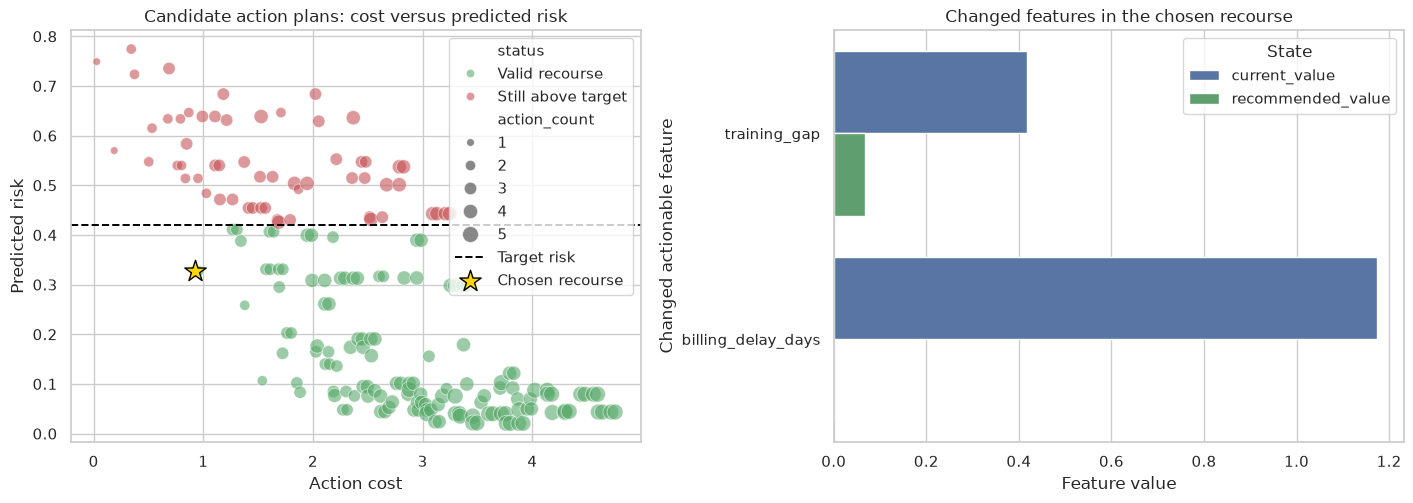

In [10]:
# Section focus: 8. Constrained Action Search.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(14.3, 5.2))

plot_candidates = focal_candidates.copy()
plot_candidates['status'] = np.where(plot_candidates['valid_recourse'], 'Valid recourse', 'Still above target')
sns.scatterplot(
    data=plot_candidates,
    x='action_cost',
    y='predicted_risk',
    hue='status',
    size='action_count',
    sizes=(30, 130),
    alpha=0.58,
    palette={'Valid recourse': '#55a868', 'Still above target': '#c44e52'},
    ax=axes[0],
)
axes[0].axhline(TARGET_RISK, color='black', linestyle='--', linewidth=1.4, label='Target risk')
axes[0].scatter(best_feasible['action_cost'], best_feasible['predicted_risk'], marker='*', s=260, color='gold', edgecolor='black', label='Chosen recourse', zorder=5)
axes[0].set_title('Candidate action plans: cost versus predicted risk')
axes[0].set_xlabel('Action cost')
axes[0].set_ylabel('Predicted risk')
axes[0].legend(loc='upper right')

before_after = pd.DataFrame(recourse_rows)
changed_before_after = before_after[before_after['change'].abs() > 1e-9].copy()
plot_before_after = changed_before_after.melt(id_vars='feature', value_vars=['current_value', 'recommended_value'], var_name='state', value_name='value')
sns.barplot(data=plot_before_after, x='value', y='feature', hue='state', ax=axes[1], palette={'current_value': '#4c72b0', 'recommended_value': '#55a868'})
axes[1].set_title('Changed features in the chosen recourse')
axes[1].set_xlabel('Feature value')
axes[1].set_ylabel('Changed actionable feature')
axes[1].legend(title='State')

plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Constrained Action Search, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Good explanations reduce ambiguity for stakeholders. Weak ones push the burden back onto human reviewers.


### Discussion of Constrained Recourse

The chosen plan is valid because the model score falls below the recourse target. It is actionable because it changes only allowed features. It is sparse because it changes only a limited number of levers. But it is still a **model-facing action plan**. It says what would move the model score, not what has already been proven to causally improve renewal outcomes.

## 9. Plausibility And Support

A recourse candidate can be actionable but still implausible. For example, reducing every risk feature to an extreme minimum might produce a favorable score, but the resulting account profile may not resemble real accounts.

We will compute a simple support diagnostic: standardized nearest-neighbor distance to the training data. Small values mean the candidate is near observed accounts. Large values mean the candidate is more extrapolative.

,case,predicted_risk,nearest_training_distance
0,Current account,0.761,0.968
1,Chosen recourse,0.327,1.661
2,Nearest observed low-risk account,0.251,0.000


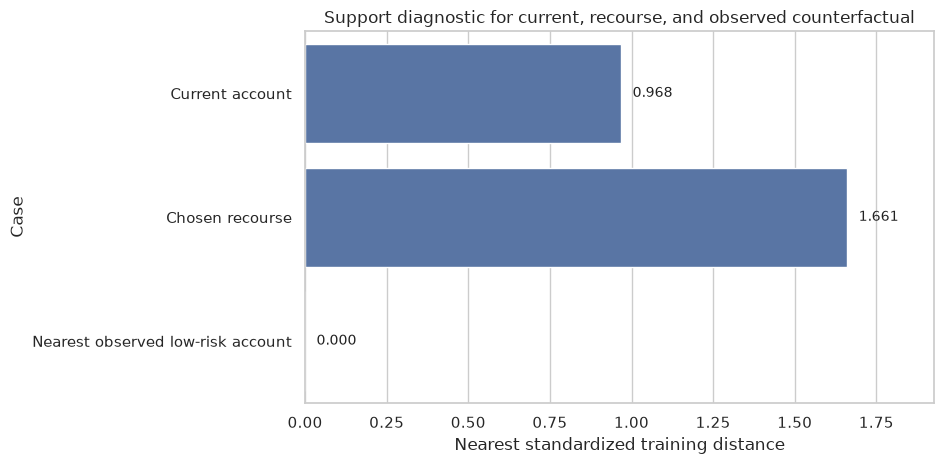

In [11]:
# Section focus: 9. Plausibility And Support.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def nearest_support_distance(records, reference, features, scaler):
    """Carry out the nearest support distance step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    records : object
        Single observation or record being converted, scored, or summarized.
    reference : object
        The reference setting that controls the nearest support distance calculation in this notebook.
    features : object
        Feature column names or feature matrix used by the model.
    scaler : object
        The scaler setting that controls the nearest support distance calculation in this notebook.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    record_matrix = scaler.transform(records[features])
    reference_matrix = scaler.transform(reference[features])
    distances = []
    for row in record_matrix:
        d = np.sqrt(((reference_matrix - row) ** 2).sum(axis=1))
        distances.append(float(d.min()))
    return np.array(distances)

support_records = pd.DataFrame([
    {**{feature: focal[feature] for feature in FEATURES}, 'case': 'Current account', 'predicted_risk': focal_risk},
    {**{feature: best_candidate_series[feature] for feature in FEATURES}, 'case': 'Chosen recourse', 'predicted_risk': best_feasible['predicted_risk']},
    {**{feature: nearest_cf[feature] for feature in FEATURES}, 'case': 'Nearest observed low-risk account', 'predicted_risk': nearest_risk},
])
support_records['nearest_training_distance'] = nearest_support_distance(support_records, train_df, FEATURES, support_scaler)
display_table(support_records[['case', 'predicted_risk', 'nearest_training_distance']])

fig, ax = plt.subplots(figsize=(9.6, 4.8))
sns.barplot(data=support_records, x='nearest_training_distance', y='case', ax=ax, color='#4c72b0')
for y_pos, distance in enumerate(support_records['nearest_training_distance']):
    label_x = distance + 0.035 if distance > 0 else 0.035
    ax.text(label_x, y_pos, f'{distance:.3f}', va='center', ha='left', fontsize=10, color='#222222')
ax.set_title('Support diagnostic for current, recourse, and observed counterfactual')
ax.set_xlabel('Nearest standardized training distance')
ax.set_ylabel('Case')
ax.set_xlim(0, max(1.9, support_records['nearest_training_distance'].max() * 1.16))
plt.tight_layout()
plt.show()

Use the explanation as a stress test of the model narrative. In Plausibility And Support, the displayed reasons should make sense with the data-generating story and the operating decision. A local story is stronger when several reasonable methods point in the same direction.


### Discussion of Plausibility

The nearest observed counterfactual is usually highly plausible by construction. The chosen recourse candidate may be slightly farther from observed data because it combines several action changes. That does not invalidate it, but it should be reported. A recourse explanation without a support diagnostic can quietly ask the model about unrealistic accounts.

## 10. Model-Only Feature Edits Can Be Misleading

Now we deliberately allow an unrealistic edit: reducing historical incident counts. This often produces cheaper or stronger model movement, but it is not short-term recourse. The account cannot rewrite the last 90 days of incidents. At most, it can take actions that reduce future incidents.

In [12]:
# Section focus: 10. Model-Only Feature Edits Can Be Misleading.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

model_only_candidates = generate_action_candidates(focal, gb_model, FEATURES, target_risk=TARGET_RISK, include_incident_edits=True)
model_only_best = best_candidate(model_only_candidates)

history_only_case = focal.copy()
history_only_case['recent_incidents'] = 0
history_only_risk = float(predict_risk(gb_model, pd.DataFrame([history_only_case[FEATURES]]), FEATURES)[0])

comparison_rows = [
    {
        'method': 'Strict actionable recourse',
        'predicted_risk': best_feasible['predicted_risk'],
        'valid_recourse': bool(best_feasible['predicted_risk'] <= TARGET_RISK),
        'action_cost': best_feasible['action_cost'],
        'action_count': int(best_feasible['action_count']),
        'changed_features': ', '.join([feature for feature in ACTIONABLE_FEATURES if abs(float(best_feasible[feature] - focal[feature])) > 1e-9]),
        'why_it_is_or_is_not_actionable': 'Allowed short-term operating levers only',
    },
    {
        'method': 'Invalid history-only edit',
        'predicted_risk': history_only_risk,
        'valid_recourse': bool(history_only_risk <= TARGET_RISK),
        'action_cost': 'Not applicable',
        'action_count': int(abs(float(history_only_case['recent_incidents'] - focal['recent_incidents'])) > 1e-9),
        'changed_features': 'recent_incidents',
        'why_it_is_or_is_not_actionable': 'Explains sensitivity, but rewrites historical incident count',
    },
]

if model_only_best is not None:
    comparison_rows.append({
        'method': 'Model-only search with incident history allowed',
        'predicted_risk': model_only_best['predicted_risk'],
        'valid_recourse': bool(model_only_best['predicted_risk'] <= TARGET_RISK),
        'action_cost': model_only_best['action_cost'],
        'action_count': int(model_only_best['action_count']),
        'changed_features': ', '.join([feature for feature in ACTIONABLE_FEATURES + ['recent_incidents'] if abs(float(model_only_best[feature] - focal[feature])) > 1e-9]),
        'why_it_is_or_is_not_actionable': 'Search permits non-actionable history edits, even when this run does not choose one',
    })

comparison = pd.DataFrame(comparison_rows)
display_table(comparison, max_width='620px')

incident_edit_rows = []
for feature in ACTIONABLE_FEATURES + ['recent_incidents']:
    incident_edit_rows.append({
        'feature': feature,
        'current_value': focal[feature],
        'strict_recourse_value': best_feasible[feature] if feature in best_feasible else focal[feature],
        'history_only_value': history_only_case[feature],
        'model_only_search_value': model_only_best[feature] if model_only_best is not None and feature in model_only_best else focal[feature],
        'short_term_actionable': feature in ACTIONABLE_FEATURES,
    })
display_table(pd.DataFrame(incident_edit_rows))

,method,predicted_risk,valid_recourse,action_cost,action_count,changed_features,why_it_is_or_is_not_actionable
0,Strict actionable recourse,0.327,True,0.923,2,"training_gap, billing_delay_days",Allowed short-term operating levers only
1,Invalid history-only edit,0.447,False,Not applicable,1,recent_incidents,"Explains sensitivity, but rewrites historical incident count"
2,Model-only search with incident history allowed,0.327,True,0.923,2,"training_gap, billing_delay_days","Search permits non-actionable history edits, even when this run does not choose one"


,feature,current_value,strict_recourse_value,history_only_value,model_only_search_value,short_term_actionable
0,usage_gap,0.332,0.332,0.332,0.332,True
1,training_gap,0.418,0.068,0.418,0.068,True
2,open_tickets,4.000,4.000,4.000,4.000,True
3,billing_delay_days,1.173,0.000,1.173,0.000,True
4,executive_sponsor,0.000,0.000,0.000,0.000,True
5,recent_incidents,2.000,2.000,0.000,2.000,False


For Model-Only Feature Edits Can Be Misleading, the explanation earns trust through stability and reviewability, not through a polished chart alone.


### Discussion of Model-Only Edits

The history-only edit is intentionally invalid as short-term recourse. It can reveal that the model is sensitive to recent incidents, but it asks the account to change the past. The broader model-only search can also mix real actions with non-actionable history edits.

This is why recourse reports must separate:

- features the model is sensitive to;
- features stakeholders can change;
- actions that are likely to change future measurements;
- actions that are causally expected to improve the underlying outcome.

## 11. Simple Causal Warning: Acceptance Versus Improvement

A recourse plan optimizes the model score. It does not prove that the real outcome improves. Karimi, Schölkopf, and Valera (2020) make this distinction by moving from feature-vector counterfactuals to interventions.

We can illustrate with a simplified mechanism. Suppose training support reduces training gap, and lower training gap partially reduces usage gap and open tickets over time. Under that mechanism, an intervention on training can propagate to other features. A pure feature edit, by contrast, treats each feature as independently adjustable.

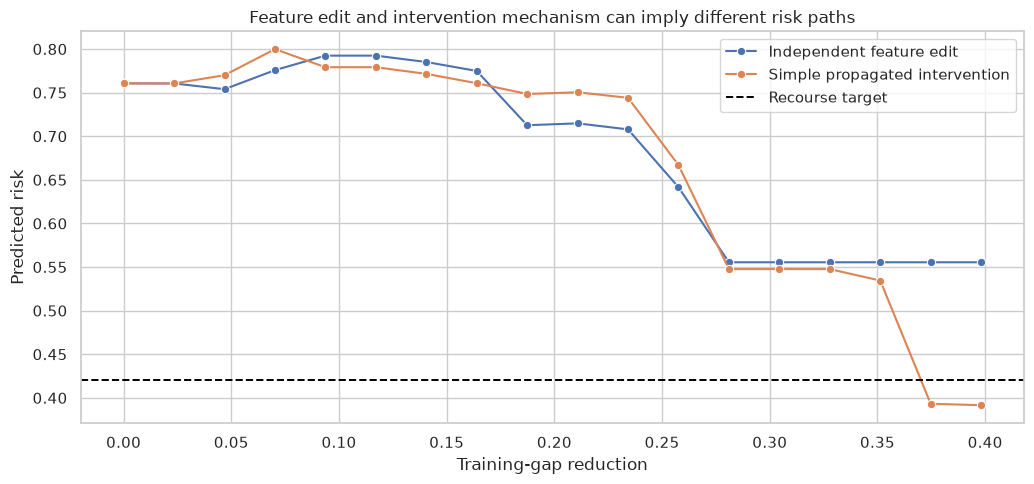

,training_gap_reduction,risk_independent_feature_edit,risk_with_simple_mechanism,mechanism_usage_gap,mechanism_open_tickets
12,0.281,0.555,0.548,0.214,3.000
13,0.304,0.555,0.548,0.204,3.000
14,0.328,0.555,0.548,0.194,3.000
15,0.351,0.555,0.534,0.185,3.000
16,0.375,0.555,0.393,0.175,3.000
17,0.398,0.555,0.392,0.165,3.000


In [13]:
# Section focus: 11. Simple Causal Warning: Acceptance Versus Improvement.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def apply_training_intervention(original, training_reduction):
    """Carry out the apply training intervention step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    original : object
        The original setting that controls the apply training intervention calculation in this notebook.
    training_reduction : object
        Training split or training value used by this workflow.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the apply training intervention calculation.
    """
    updated = original.copy()
    training_reduction = max(float(training_reduction), 0)
    updated['training_gap'] = max(original['training_gap'] - training_reduction, 0.02)
    realized_training_reduction = original['training_gap'] - updated['training_gap']
    updated['usage_gap'] = max(original['usage_gap'] - 0.42 * realized_training_reduction, 0.02)
    updated['open_tickets'] = max(int(round(original['open_tickets'] - 2.0 * realized_training_reduction)), 0)
    updated['billing_delay_days'] = original['billing_delay_days']
    updated['executive_sponsor'] = original['executive_sponsor']
    return updated

training_grid = np.linspace(0, min(float(focal['training_gap'] - 0.02), 0.60), 18)
mechanism_rows = []
for reduction in training_grid:
    mechanism_case = apply_training_intervention(focal, reduction)
    independent_case = focal.copy()
    independent_case['training_gap'] = max(focal['training_gap'] - reduction, 0.02)
    mechanism_rows.append({
        'training_gap_reduction': reduction,
        'risk_independent_feature_edit': float(predict_risk(gb_model, pd.DataFrame([independent_case[FEATURES]]), FEATURES)[0]),
        'risk_with_simple_mechanism': float(predict_risk(gb_model, pd.DataFrame([mechanism_case[FEATURES]]), FEATURES)[0]),
        'mechanism_usage_gap': mechanism_case['usage_gap'],
        'mechanism_open_tickets': mechanism_case['open_tickets'],
    })
mechanism_df = pd.DataFrame(mechanism_rows)

fig, ax = plt.subplots(figsize=(10.5, 5.0))
sns.lineplot(data=mechanism_df, x='training_gap_reduction', y='risk_independent_feature_edit', marker='o', label='Independent feature edit', ax=ax)
sns.lineplot(data=mechanism_df, x='training_gap_reduction', y='risk_with_simple_mechanism', marker='o', label='Simple propagated intervention', ax=ax)
ax.axhline(TARGET_RISK, color='black', linestyle='--', linewidth=1.4, label='Recourse target')
ax.set_title('Feature edit and intervention mechanism can imply different risk paths')
ax.set_xlabel('Training-gap reduction')
ax.set_ylabel('Predicted risk')
ax.legend()
plt.tight_layout()
plt.show()

display_table(mechanism_df.tail(6))

Use Simple Causal Warning: Acceptance Versus Improvement to test whether the explanation story is credible. The displayed reasons should line up with the data-generating story and the operating decision, and unstable attributions should be called out clearly.


### Discussion of The Causal Warning

The two curves answer different questions. The independent feature edit asks what the model predicts if only training gap changes. The propagated intervention asks what the model predicts if training improvement also changes usage and ticket burden through a simple mechanism.

Neither curve is a causal estimate unless the mechanism is justified. The point is conceptual: recourse should not silently treat correlated features as independently manipulable.

## 12. Recourse Burden Across Segments

Recourse can be unequal. Some groups may have many low-cost paths to a favorable model outcome. Others may need larger changes or may have no feasible path in the allowed action set. Fairness work on recourse studies exactly this kind of burden (von Kugelgen et al., 2022).

We will audit high-risk test accounts and estimate the lowest-cost feasible recourse plan under the same action grid.

In [14]:
# Section focus: 12. Recourse Burden Across Segments.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def recourse_for_account(row, model, features, target_risk=TARGET_RISK):
    """Carry out the recourse for account step used in the 11. Counterfactual Explanations and Actionable Recourse workflow.
    
    Parameters
    ----------
    row : object
        Single data-frame row representing one unit in the current decision example.
    model : object
        Fitted model or model specification used by this step.
    features : object
        Feature column names or feature matrix used by the model.
    target_risk : object
        Score or risk value used for ranking, thresholding, or diagnostics.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    candidates = generate_action_candidates(row, model, features, target_risk=target_risk, include_incident_edits=False)
    best = best_candidate(candidates)
    if best is None:
        return {
            'success': False,
            'recourse_cost': np.nan,
            'recourse_risk': np.nan,
            'action_count': np.nan,
        }
    return {
        'success': True,
        'recourse_cost': best['action_cost'],
        'recourse_risk': best['predicted_risk'],
        'action_count': best['action_count'],
    }

high_risk_pool = test_df.loc[test_predictions >= REVIEW_THRESHOLD].copy()
high_risk_pool = high_risk_pool.assign(predicted_risk=test_predictions.loc[high_risk_pool.index])
audit_sample = high_risk_pool.sample(min(160, len(high_risk_pool)), random_state=RANDOM_SEED).copy()

audit_rows = []
for idx, row in audit_sample.iterrows():
    result = recourse_for_account(row, gb_model, FEATURES, target_risk=TARGET_RISK)
    audit_rows.append({
        'row_index': idx,
        'predicted_risk': row['predicted_risk'],
        'executive_sponsor': int(row['executive_sponsor']),
        'legacy_integration': int(row['legacy_integration']),
        'international_region': int(row['international_region']),
        **result,
    })

audit = pd.DataFrame(audit_rows)
audit['sponsor_segment'] = np.where(audit['executive_sponsor'].eq(1), 'Sponsor present', 'No sponsor')
audit['legacy_segment'] = np.where(audit['legacy_integration'].eq(1), 'Legacy integration', 'Modern integration')

summary_by_sponsor = (
    audit.groupby('sponsor_segment')
    .agg(
        accounts=('row_index', 'count'),
        success_rate=('success', 'mean'),
        median_cost=('recourse_cost', 'median'),
        p90_cost=('recourse_cost', lambda s: np.nanquantile(s, 0.90)),
        mean_actions=('action_count', 'mean'),
    )
    .reset_index()
)
summary_by_legacy = (
    audit.groupby('legacy_segment')
    .agg(
        accounts=('row_index', 'count'),
        success_rate=('success', 'mean'),
        median_cost=('recourse_cost', 'median'),
        p90_cost=('recourse_cost', lambda s: np.nanquantile(s, 0.90)),
        mean_actions=('action_count', 'mean'),
    )
    .reset_index()
)

display_table(summary_by_sponsor)
display_table(summary_by_legacy)

,sponsor_segment,accounts,success_rate,median_cost,p90_cost,mean_actions
0,No sponsor,104,0.933,1.378,3.771,2.381
1,Sponsor present,56,0.982,0.923,2.892,2.109


,legacy_segment,accounts,success_rate,median_cost,p90_cost,mean_actions
0,Legacy integration,102,0.931,1.556,3.751,2.442
1,Modern integration,58,0.983,0.906,1.994,2.018


For Recourse Burden Across Segments, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


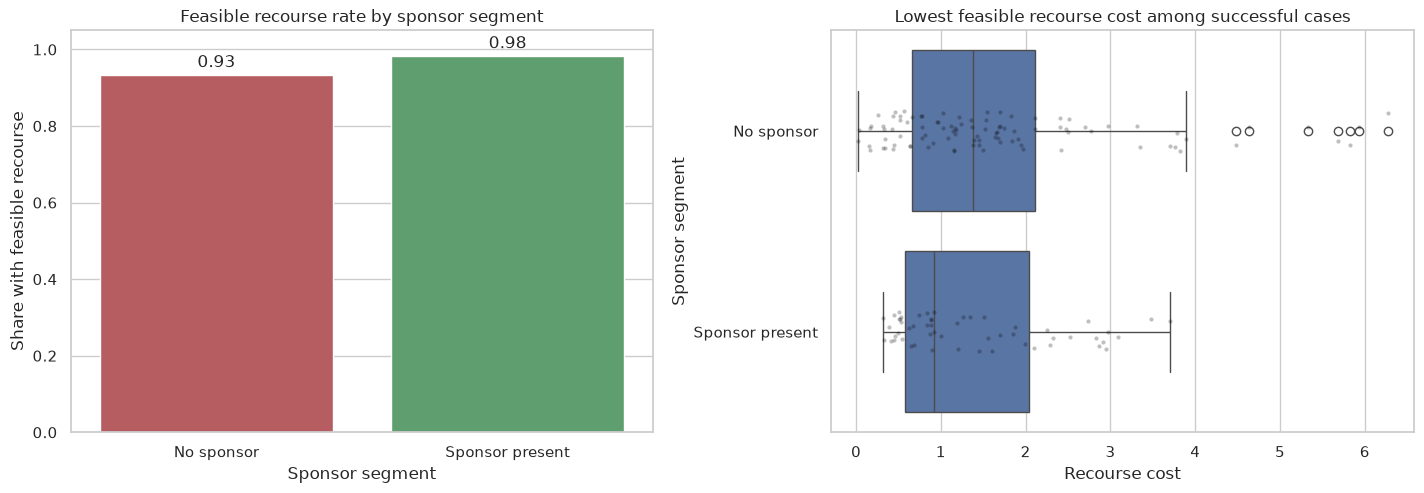

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.1))

success_plot = audit.groupby('sponsor_segment', as_index=False)['success'].mean()
sns.barplot(data=success_plot, x='sponsor_segment', y='success', hue='sponsor_segment', ax=axes[0], palette={'No sponsor': '#c44e52', 'Sponsor present': '#55a868'}, legend=False)
axes[0].set_title('Feasible recourse rate by sponsor segment')
axes[0].set_xlabel('Sponsor segment')
axes[0].set_ylabel('Share with feasible recourse')
axes[0].set_ylim(0, 1.05)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3)

sns.boxplot(data=audit[audit['success']], x='recourse_cost', y='sponsor_segment', ax=axes[1], color='#4c72b0')
sns.stripplot(data=audit[audit['success']], x='recourse_cost', y='sponsor_segment', ax=axes[1], color='black', alpha=0.25, size=3)
axes[1].set_title('Lowest feasible recourse cost among successful cases')
axes[1].set_xlabel('Recourse cost')
axes[1].set_ylabel('Sponsor segment')

plt.tight_layout()
plt.show()

Recourse Burden Across Segments is useful only if the explanation remains credible under reasonable modeling choices.


### Discussion of Recourse Burden

The audit asks whether recourse is available and how costly it is under the chosen action set. Differences across segments may reflect many things: model behavior, feature distributions, operational constraints, and the action grid. They should not be reduced to a single fairness verdict, but they are exactly the kind of evidence a governance review should inspect.

## 13. Robustness Over Time

A counterfactual can fail after model retraining. Ferrario and Loi (2022) study robustness of counterfactual explanations over time. In practice, this matters because a stakeholder may invest effort in a recourse plan, only to face a changed model later.

We simulate a simple model update by retraining on a bootstrap sample. Then we ask whether the chosen recourse remains valid.

,case,risk_under_original_model,risk_under_retrained_model,valid_under_original_model,valid_under_retrained_model
0,Current account,0.761,0.767,False,False
1,Chosen recourse,0.327,0.419,True,True


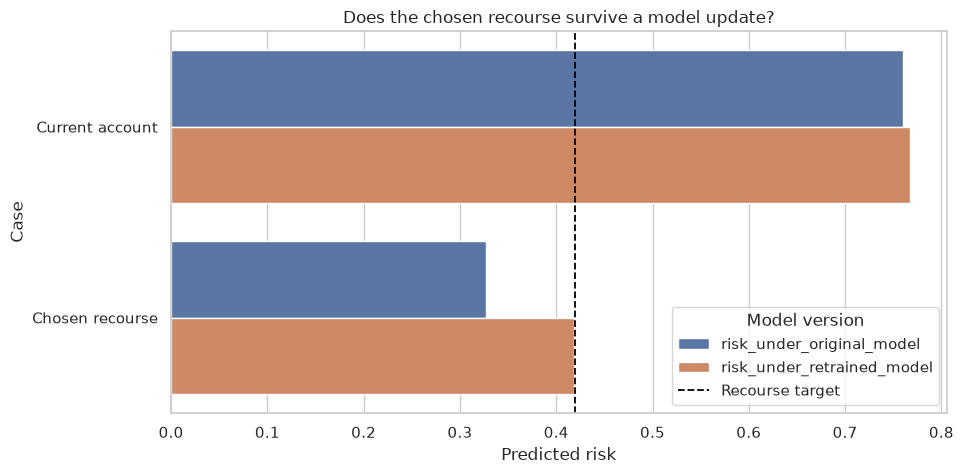

In [16]:
# Section focus: 13. Robustness Over Time.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

bootstrap_train = train_df.sample(frac=1.0, replace=True, random_state=RANDOM_SEED + 31)
gb_model_v2 = HistGradientBoostingClassifier(
    max_iter=260,
    learning_rate=0.045,
    max_leaf_nodes=24,
    l2_regularization=0.03,
    random_state=RANDOM_SEED + 31,
)
gb_model_v2.fit(bootstrap_train[FEATURES], bootstrap_train[TARGET])

current_case_df = pd.DataFrame([focal[FEATURES]])
recourse_case_df = pd.DataFrame([best_candidate_series[FEATURES]])
robustness = pd.DataFrame([
    {
        'case': 'Current account',
        'risk_under_original_model': float(predict_risk(gb_model, current_case_df, FEATURES)[0]),
        'risk_under_retrained_model': float(predict_risk(gb_model_v2, current_case_df, FEATURES)[0]),
    },
    {
        'case': 'Chosen recourse',
        'risk_under_original_model': float(predict_risk(gb_model, recourse_case_df, FEATURES)[0]),
        'risk_under_retrained_model': float(predict_risk(gb_model_v2, recourse_case_df, FEATURES)[0]),
    },
])
robustness['valid_under_original_model'] = robustness['risk_under_original_model'] <= TARGET_RISK
robustness['valid_under_retrained_model'] = robustness['risk_under_retrained_model'] <= TARGET_RISK
display_table(robustness)

fig, ax = plt.subplots(figsize=(9.8, 4.9))
plot_robust = robustness.melt(id_vars='case', value_vars=['risk_under_original_model', 'risk_under_retrained_model'], var_name='model_version', value_name='predicted_risk')
sns.barplot(data=plot_robust, x='predicted_risk', y='case', hue='model_version', ax=ax, palette='deep')
ax.axvline(TARGET_RISK, color='black', linestyle='--', linewidth=1.3, label='Recourse target')
ax.set_title('Does the chosen recourse survive a model update?')
ax.set_xlabel('Predicted risk')
ax.set_ylabel('Case')
ax.legend(title='Model version')
plt.tight_layout()
plt.show()

In Robustness Over Time, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. A stable story can be stated more directly; a setting-sensitive one needs caution.


### Discussion of Robustness

If the chosen recourse remains below the target under the retrained model, it is more credible. If it fails, the original explanation may still be mathematically correct, but the organization should avoid presenting recourse as a permanent guarantee unless model updates, data drift, and policy changes are governed.

## 14. A Professional Recourse Report

A useful recourse report should include feasibility, robustness, and actionability, not a bare "change X by Y" instruction:

| Report component | What to include |
|---|---|
| Decision context | Model, unfavorable outcome, threshold, and recourse target |
| Current case | Current feature values and prediction |
| Action set | Which features can and cannot change |
| Cost model | How action burden is measured |
| Recommended plan | Feature changes, predicted risk after changes, and margin to target |
| Plausibility | Support diagnostic or nearest-neighbor evidence |
| Robustness | Whether the plan survives model retraining or sensitivity checks |
| Equity audit | Recourse success and cost by relevant segments |
| Causal caveat | Whether actions are expected to improve the real outcome, alongside the model score |

A strong wording pattern is:

> Under the current model and action set, this account can be moved below the review-risk target by reducing the training gap and resolving billing delay. This is valid model recourse, not proof that these actions causally guarantee renewal success.

## 15. Key Takeaways

- Counterfactual explanations find nearby feature vectors with desired model outcomes.
- Actionable recourse adds feasibility, directionality, cost, sparsity, and plausibility constraints.
- Nearest observed low-risk examples can be useful contrasts, but they still need feasibility checks before becoming action plans.
- Allowing non-actionable feature edits can make recourse look easier than it really is.
- Recourse should distinguish model acceptance from real-world improvement.
- Recourse burden should be audited across operational and protected segments.
- Counterfactual advice can become invalid after model retraining, so robustness monitoring matters.

## References

- Ferrario, A., & Loi, M. (2022). *The robustness of counterfactual explanations over time*. *IEEE Access, 10*, 82736-82750. [https://doi.org/10.1109/access.2022.3196917](https://doi.org/10.1109/access.2022.3196917)
- Karimi, A.-H., Schölkopf, B., & Valera, I. (2020). *Algorithmic recourse: From counterfactual explanations to interventions*. arXiv. [https://doi.org/10.48550/arxiv.2002.06278](https://doi.org/10.48550/arxiv.2002.06278)
- Karimi, A.-H., von Kügelgen, J., & Schölkopf, B. (2020). *Algorithmic recourse under imperfect causal knowledge: A probabilistic approach*. arXiv. [https://doi.org/10.48550/arxiv.2006.06831](https://doi.org/10.48550/arxiv.2006.06831)
- Ustun, B., Spangher, A., & Liu, Y. (2019). *Actionable recourse in linear classification*. *Proceedings of the Conference on Fairness, Accountability, and Transparency*, 10-19. [https://doi.org/10.1145/3287560.3287566](https://doi.org/10.1145/3287560.3287566)
- Verma, S., Boonsanong, V., Hoang, M., Hines, K., Dickerson, J. P., & Shah, C. (2020). *Counterfactual explanations and algorithmic recourses for machine learning: A review*. arXiv. [https://doi.org/10.48550/arxiv.2010.10596](https://doi.org/10.48550/arxiv.2010.10596)
- von Kügelgen, J., Karimi, A.-H., Bhatt, U., Valera, I., Weller, A., & Schölkopf, B. (2022). *On the fairness of causal algorithmic recourse*. *Proceedings of the AAAI Conference on Artificial Intelligence, 36*(9), 9584-9594. [https://doi.org/10.1609/aaai.v36i9.21192](https://doi.org/10.1609/aaai.v36i9.21192)
- Wachter, S., Mittelstadt, B., & Russell, C. (2017). *Counterfactual explanations without opening the black box: Automated decisions and the GDPR*. *SSRN Electronic Journal*. [https://doi.org/10.2139/ssrn.3063289](https://doi.org/10.2139/ssrn.3063289)
